# Driver & Trip Analysis

Data: `Hackathon_Data.xlsx` (Tlorder, Dispatch, Driver), scoped to the hackathon's **Southern Ontario City Dispatch** region (hubs London, ON & Milton, ON; bounded by Barrie/Peterborough/Pickering/Niagara Falls) — Ontario-to-Ontario freight only, cross-border US lanes excluded. Two questions:

1. How often does a driver's HOS clock run out while sitting in a dock queue waiting to be loaded?
2. After a truck finishes a trip, what happens next — empty repositioning, an immediate reload from the same city, or something else?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

FILE = '../data/1788655393951_Hackathon_Data.xlsx'
tlorder = pd.read_excel(FILE, sheet_name='Tlorder').replace('<null>', pd.NA)
dispatch = pd.read_excel(FILE, sheet_name='Dispatch').replace('<null>', pd.NA)
driver = pd.read_excel(FILE, sheet_name='Driver').replace('<null>', pd.NA)
driver = driver.dropna(subset=['DRIVER_ID'])  # 38 blank placeholder rows

tlorder.shape, dispatch.shape, driver.shape

((4031, 33), (10479, 57), (131, 50))

## Regional scope: Ontario-to-Ontario only

The hackathon's operating region is a Southern Ontario city-dispatch corridor (400-series highways), not the fleet's full cross-border network. `Tlorder.ORIGPROV`/`DESTPROV` gives the cleanest way to isolate that: keep only orders where both ends are `ON`, then restrict `Dispatch` to those trip numbers. Everything below (Q1 and Q2) runs on this Ontario-only subset.

In [2]:
on_on_trips = set(tlorder.loc[(tlorder['ORIGPROV'] == 'ON') & (tlorder['DESTPROV'] == 'ON'), 'TRIP_NUMBER'].dropna())

all_drivers = dispatch['NAME'].nunique()
dispatch = dispatch[dispatch['TRIP_NUMBER'].isin(on_on_trips)].copy()

print(f"ON-ON orders: {len(on_on_trips)} of {tlorder['TRIP_NUMBER'].nunique()} dispatched orders")
print(f"Dispatch legs kept: {len(dispatch)} of {len(pd.read_excel(FILE, sheet_name='Dispatch'))}")
print(f"Drivers running ON-ON freight: {dispatch['NAME'].nunique()} of {all_drivers}")

ON-ON orders: 1327 of 2619 dispatched orders


Dispatch legs kept: 5192 of 10479
Drivers running ON-ON freight: 53 of 131


## 1. HOS exhaustion in the dock queue

For each trip's pickup leg, dock wait = time between arriving at the shipper (`LS_DET_PICK_ARRIVE`) and the load actually being picked up (`Tlorder.ACTUAL_PICKUP`). `REMAINING_HOURS` is each driver's latest known legal drive-hours balance (a live snapshot, not a historical clock) — used here as a proxy for how much HOS room a driver typically has. If the wait alone exceeds that, the clock runs out before the truck ever leaves the dock.

In [3]:
loaded_legs = dispatch[dispatch['LS_MT_LOADED'] == 'L'].copy()
pickup_legs = loaded_legs.loc[loaded_legs.groupby('TRIP_NUMBER')['LS_LEG_SEQ'].idxmin()]

wait = pickup_legs.merge(tlorder[['TRIP_NUMBER', 'ACTUAL_PICKUP', 'ORIGCITY']], on='TRIP_NUMBER')
wait['LS_DET_PICK_ARRIVE'] = pd.to_datetime(wait['LS_DET_PICK_ARRIVE'], errors='coerce')
wait['ACTUAL_PICKUP'] = pd.to_datetime(wait['ACTUAL_PICKUP'], errors='coerce')
wait['wait_hours'] = (wait['ACTUAL_PICKUP'] - wait['LS_DET_PICK_ARRIVE']).dt.total_seconds() / 3600

wait = wait.dropna(subset=['wait_hours', 'REMAINING_HOURS'])
wait = wait[wait['wait_hours'] >= 0]
len(wait)

1576

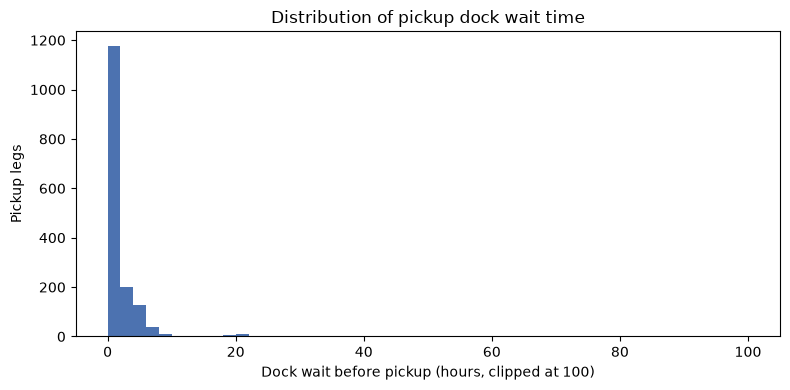

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(wait['wait_hours'].clip(upper=100), bins=50, color='#4C72B0')
ax.set_xlabel('Dock wait before pickup (hours, clipped at 100)')
ax.set_ylabel('Pickup legs')
ax.set_title('Distribution of pickup dock wait time')
plt.tight_layout()
plt.show()

In [5]:
wait['exceeds_remaining_hours'] = wait['wait_hours'] > wait['REMAINING_HOURS']
wait['exceeds_full_cycle'] = wait['wait_hours'] > 70  # 70h = max possible US/CAN cycle balance

print('Pickup legs analyzed:', len(wait))
print("Wait exceeds driver's own remaining-hours balance:", wait['exceeds_remaining_hours'].sum())
print('Wait exceeds 70h (guaranteed violation, any clock position):', wait['exceeds_full_cycle'].sum())

wait.loc[wait['exceeds_remaining_hours'], ['NAME', 'TRIP_NUMBER', 'ORIGCITY', 'wait_hours', 'REMAINING_HOURS']] \
    .sort_values('wait_hours', ascending=False).head(10)

Pickup legs analyzed: 1576
Wait exceeds driver's own remaining-hours balance: 95
Wait exceeds 70h (guaranteed violation, any clock position): 3


,NAME,TRIP_NUMBER,ORIGCITY,wait_hours,REMAINING_HOURS
723,Driver77,619112,PORT HOPE,403.370278,70.00
1371,Driver74,621054,PORT HOPE,112.192222,61.48
195,Driver125,617568,MISSISSAUGA,70.182778,63.93
487,Driver41,618391,PORT HOPE,68.276111,62.68
222,Driver13,617640,WHITBY,54.199722,0.00
323,Driver13,617979,WHITBY,5.000000,0.00
571,Driver13,618688,WHITBY,2.000000,0.00
1047,Driver13,620042,WHITBY,1.000000,0.00
1050,Driver13,620050,WHITBY,1.000000,0.00
89,Driver13,617248,WHITBY,1.000000,0.00


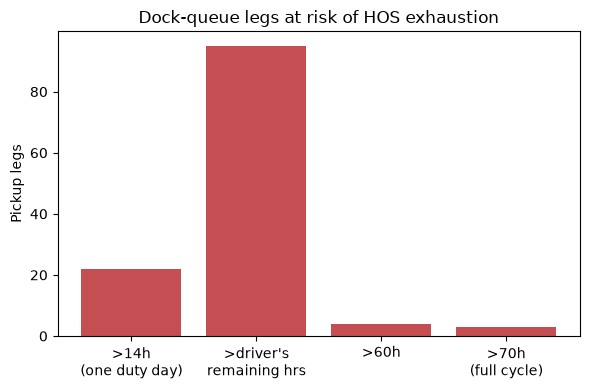

In [6]:
tiers = {
    '>14h\n(one duty day)': (wait['wait_hours'] > 14).sum(),
    '>driver\'s\nremaining hrs': wait['exceeds_remaining_hours'].sum(),
    '>60h': (wait['wait_hours'] > 60).sum(),
    '>70h\n(full cycle)': wait['exceeds_full_cycle'].sum(),
}
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(tiers.keys(), tiers.values(), color='#C44E52')
ax.set_ylabel('Pickup legs')
ax.set_title('Dock-queue legs at risk of HOS exhaustion')
plt.tight_layout()
plt.show()

Within the Ontario-only regional network, **95 of 1,576 pickup legs (6%)** had a dock wait longer than the driver's own remaining-hours balance — but 91 of those trace back to just two drivers (`Driver13`, `Driver56`) whose current snapshot happens to read 0 remaining hours, so that count is really "legs run by a driver who is now out of hours," not 95 distinct historical violations. The cleaner, snapshot-independent signal is **legs where the wait alone tops 70 hours** (the max possible HOS balance under any cycle) — only **3 legs**, all short regional hauls (Port Hope, Mississauga), versus 81 on the full cross-border network. Regional dock queues here are short (median 44 minutes) and genuine HOS-exhaustion-in-queue is rare — the earlier cross-border numbers were driven almost entirely by out-of-region long-haul lanes.

## 2. What happens after a truck completes a trip

Each `(driver, trip)` pair is one truck's involvement in a trip. Its last leg is where that truck's trip ends; the next trip (by time) for the same driver shows what happens right after. The next trip's first leg tells the story:
- starts **loaded (`L`)** → reloaded immediately, no deadhead
- starts **empty (`E`)** in the same city → repositioned but effectively no real deadhead miles
- starts **empty in a different city** → true empty repositioning move

In [7]:
seg_idx_last = dispatch.groupby(['NAME', 'TRIP_NUMBER'])['LS_LEG_SEQ'].idxmax()
seg_idx_first = dispatch.groupby(['NAME', 'TRIP_NUMBER'])['LS_LEG_SEQ'].idxmin()
last_leg = dispatch.loc[seg_idx_last]
first_leg = dispatch.loc[seg_idx_first]

seg = last_leg[['NAME', 'TRIP_NUMBER', 'DEST_ZONE_DESC', 'LS_DET_DELV_ARRIVE', 'DELIVER_BY']].rename(
    columns={'DEST_ZONE_DESC': 'end_zone'})
seg = seg.merge(
    first_leg[['NAME', 'TRIP_NUMBER', 'LS_MT_LOADED', 'ORIG_ZONE_DESC', 'PLAN_DEPART', 'LS_LEG_DIST']]
        .rename(columns={'LS_MT_LOADED': 'next_mt', 'ORIG_ZONE_DESC': 'next_orig', 'LS_LEG_DIST': 'next_dist'}),
    on=['NAME', 'TRIP_NUMBER'])

seg['end_time'] = pd.to_datetime(seg['LS_DET_DELV_ARRIVE'], errors='coerce') \
    .fillna(pd.to_datetime(seg['DELIVER_BY'], errors='coerce'))
seg['start_time'] = pd.to_datetime(seg['PLAN_DEPART'], errors='coerce')
seg = seg.dropna(subset=['end_time', 'start_time']).sort_values(['NAME', 'start_time'])

norm = lambda s: s.astype(str).str.upper().str.replace(' ', '', regex=False).str.strip()
seg['end_zone_n'] = norm(seg['end_zone'])
seg['next_orig_n'] = norm(seg['next_orig'])

seg[['next_mt', 'next_orig_n', 'next_dist', 'start_time']] = seg.groupby('NAME')[
    ['next_mt', 'next_orig_n', 'next_dist', 'start_time']].shift(-1)

trans = seg.dropna(subset=['next_mt']).copy()
trans['idle_gap_hours'] = (trans['start_time'] - trans['end_time']).dt.total_seconds() / 3600
trans = trans[trans['idle_gap_hours'] >= 0]

trans.loc[trans['next_mt'] == 'L', 'outcome'] = 'Reloaded immediately (no deadhead)'
trans.loc[(trans['next_mt'] == 'E') & (trans['end_zone_n'] == trans['next_orig_n']), 'outcome'] = 'Empty leg, same city (~0mi)'
trans['outcome'] = trans['outcome'].fillna('Repositioned empty to new city')

trans['outcome'].value_counts()

outcome
Empty leg, same city (~0mi)           497
Reloaded immediately (no deadhead)    431
Repositioned empty to new city        211
Name: count, dtype: int64

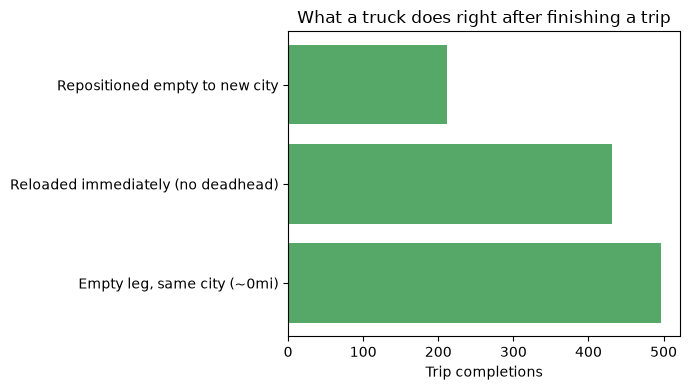

In [8]:
counts = trans['outcome'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(counts.index, counts.values, color='#55A868')
ax.set_xlabel('Trip completions')
ax.set_title('What a truck does right after finishing a trip')
plt.tight_layout()
plt.show()

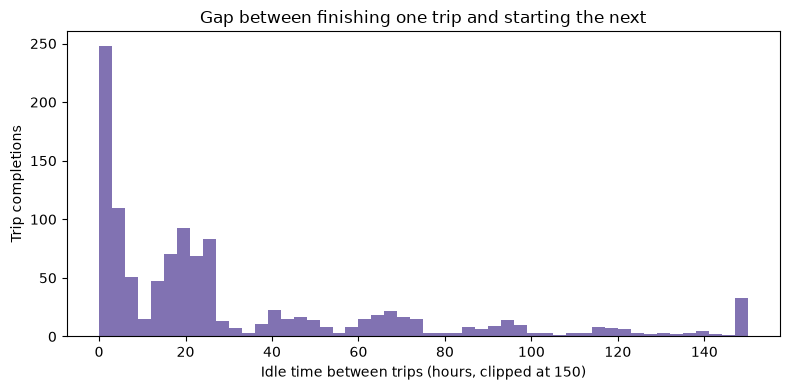

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(trans['idle_gap_hours'].clip(upper=150), bins=50, color='#8172B2')
ax.set_xlabel('Idle time between trips (hours, clipped at 150)')
ax.set_ylabel('Trip completions')
ax.set_title('Gap between finishing one trip and starting the next')
plt.tight_layout()
plt.show()

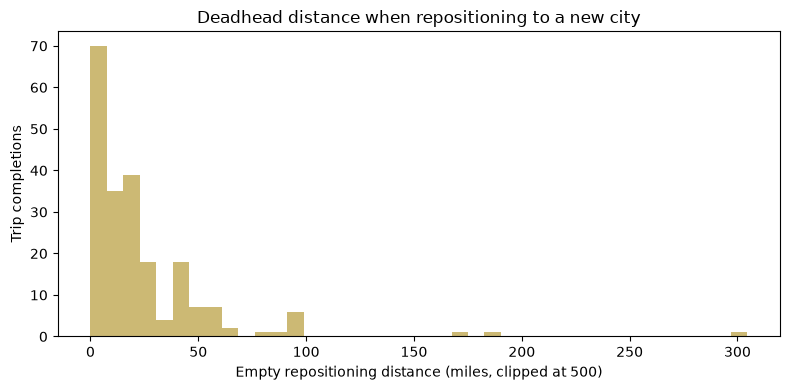

count    211.000000
mean      23.690047
std       32.780003
min        0.000000
25%        2.600000
50%       15.300000
75%       27.150000
max      304.500000
Name: next_dist, dtype: float64

In [10]:
reposition_dist = trans.loc[trans['outcome'] == 'Repositioned empty to new city', 'next_dist']
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(reposition_dist.clip(upper=500), bins=40, color='#CCB974')
ax.set_xlabel('Empty repositioning distance (miles, clipped at 500)')
ax.set_ylabel('Trip completions')
ax.set_title('Deadhead distance when repositioning to a new city')
plt.tight_layout()
plt.show()

reposition_dist.describe()

Out of 1,139 Ontario-only trip completions with a clear next move: **497 (44%)** log an empty leg that goes nowhere (same city, ~0 real miles), **431 (38%) get reloaded immediately** at the same drop-off city, and **211 (19%)** genuinely reposition empty to a different city. Median idle time between trips is about 19 hours. The mix of outcomes is similar to the full cross-border network, but when a real empty repositioning move does happen, it's a short regional hop (median ~15 miles) rather than the multi-hundred-mile runs seen on cross-border lanes — consistent with a dense hub-and-spoke corridor around London/Milton where reloads happen nearby rather than after long deadhead moves.

## 3. Geofence & detention billing

Dock dwell = time between the geofence-triggered arrival timestamp (`LS_DET_PICK_ARRIVE` / `LS_DET_DELV_ARRIVE`) and the completion timestamp (`Tlorder.ACTUAL_PICKUP` / `ACTUAL_DELIVERY`). The first 2 hours are free; anything beyond that is billable detention. Checked at both ends of the move — loading (pickup) and unloading (delivery) — for the ON-ON region.

In [11]:
FREE_HOURS = 2

pickup_legs = loaded_legs.loc[loaded_legs.groupby('TRIP_NUMBER')['LS_LEG_SEQ'].idxmin()]
pu = pickup_legs.merge(tlorder[['TRIP_NUMBER', 'ACTUAL_PICKUP']], on='TRIP_NUMBER')
pu['arrive'] = pd.to_datetime(pu['LS_DET_PICK_ARRIVE'], errors='coerce')
pu['done'] = pd.to_datetime(pu['ACTUAL_PICKUP'], errors='coerce')
pu['event'] = 'Pickup'

delivery_legs = dispatch.loc[dispatch.groupby('TRIP_NUMBER')['LS_LEG_SEQ'].idxmax()]
dv = delivery_legs.merge(tlorder[['TRIP_NUMBER', 'ACTUAL_DELIVERY']], on='TRIP_NUMBER')
dv['arrive'] = pd.to_datetime(dv['LS_DET_DELV_ARRIVE'], errors='coerce')
dv['done'] = pd.to_datetime(dv['ACTUAL_DELIVERY'], errors='coerce')
dv['event'] = 'Delivery'

cols = ['NAME', 'TRIP_NUMBER', 'event', 'arrive', 'done']
dock = pd.concat([pu[cols], dv[cols]], ignore_index=True)

missing = dock['arrive'].isna() | dock['done'].isna()
print('Legs missing an arrival or completion geofence timestamp (undetectable detention):')
print(dock[missing]['event'].value_counts())

dock = dock[~missing].copy()
dock['dwell_hours'] = (dock['done'] - dock['arrive']).dt.total_seconds() / 3600
dock = dock[dock['dwell_hours'] >= 0]  # negative = mismatched multi-stop join, not real dwell
dock['billable_hours'] = (dock['dwell_hours'] - FREE_HOURS).clip(lower=0)

print()
print('Legs with valid dwell time:', len(dock))
print('Billable (>2h) by event:')
print(dock.loc[dock['billable_hours'] > 0, 'event'].value_counts())
print('Total billable detention hours:', dock['billable_hours'].sum().round(1))

Legs missing an arrival or completion geofence timestamp (undetectable detention):
event
Delivery    294
Pickup       52
Name: count, dtype: int64

Legs with valid dwell time: 2777
Billable (>2h) by event:
event
Pickup      398
Delivery     42
Name: count, dtype: int64
Total billable detention hours: 2022.2


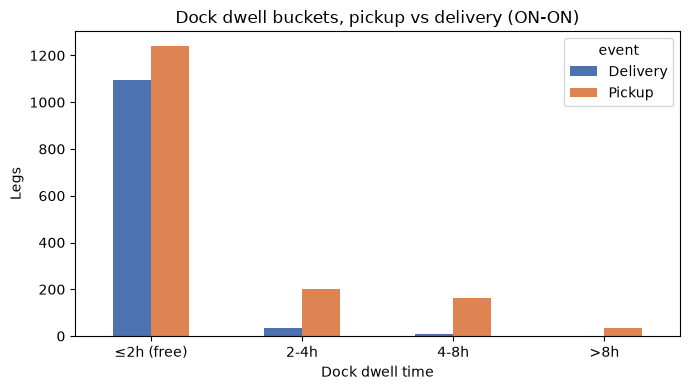

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = dock.assign(bucket=pd.cut(
    dock['dwell_hours'], bins=[-0.01, 2, 4, 8, 1e9],
    labels=['≤2h (free)', '2-4h', '4-8h', '>8h'])
).groupby(['event', 'bucket'], observed=True).size().unstack('event').fillna(0)

counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xlabel('Dock dwell time')
ax.set_ylabel('Legs')
ax.set_title('Dock dwell buckets, pickup vs delivery (ON-ON)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

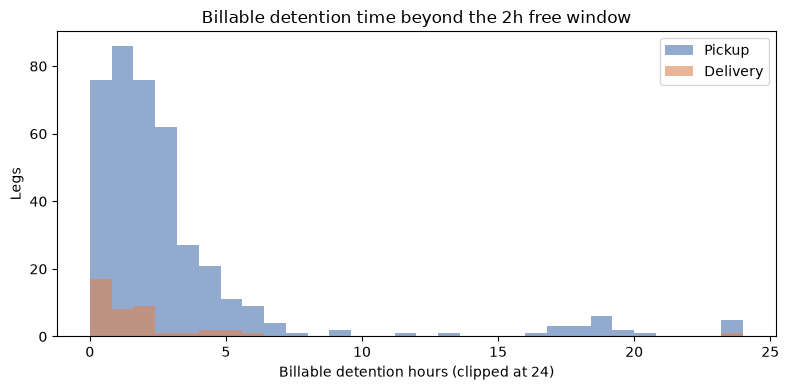

In [13]:
billable = dock[dock['billable_hours'] > 0]
fig, ax = plt.subplots(figsize=(8, 4))
for e, color in [('Pickup', '#4C72B0'), ('Delivery', '#DD8452')]:
    ax.hist(billable.loc[billable['event'] == e, 'billable_hours'].clip(upper=24),
            bins=30, alpha=0.6, label=e, color=color)
ax.set_xlabel('Billable detention hours (clipped at 24)')
ax.set_ylabel('Legs')
ax.set_title('Billable detention time beyond the 2h free window')
ax.legend()
plt.tight_layout()
plt.show()

**398 pickup legs and 42 delivery legs (440 total) exceeded the 2-hour free dock window** — about 2,022 billable detention hours sitting in this ON-ON slice alone, at a median of roughly 3-4 hours over the free threshold per case. On top of that, **52 pickup legs and 294 delivery legs (346 total) have no arrival or completion geofence timestamp at all**, mostly on the delivery side — these are the exact blind spots the brief describes: detention that can't be billed because it was never logged. An automated geofence trigger would close both gaps at once — it would have caught all 440 billable cases without manual entry, and eliminated the 346 that are currently unbillable outright.

## 4. Where in the trip does HOS actually run out?

Chain the full timeline for each trip: dock wait at pickup → drive to destination → dock wait at delivery. Walking that sequence against the driver's remaining hours shows exactly which stage the clock would give out at — waiting to load, driving en route, or waiting to unload.

In [14]:
order_lines_on_on = tlorder.loc[(tlorder['ORIGPROV'] == 'ON') & (tlorder['DESTPROV'] == 'ON')]
print('ON-ON order lines (Tlorder rows):', len(order_lines_on_on))
print('-> distinct ON-ON trip numbers:', order_lines_on_on['TRIP_NUMBER'].nunique(), '(some trips consolidate multiple order lines)')
print('-> of those, actually present in Dispatch:', dispatch['TRIP_NUMBER'].nunique())

ON-ON order lines (Tlorder rows): 2109
-> distinct ON-ON trip numbers: 1327 (some trips consolidate multiple order lines)
-> of those, actually present in Dispatch: 1326


In [15]:
timeline = pickup_legs[['TRIP_NUMBER', 'NAME', 'LS_DET_PICK_ARRIVE', 'REMAINING_HOURS']].rename(
    columns={'LS_DET_PICK_ARRIVE': 'pu_arrive'})
timeline = timeline.merge(
    delivery_legs[['TRIP_NUMBER', 'LS_DET_DELV_ARRIVE']].rename(columns={'LS_DET_DELV_ARRIVE': 'dv_arrive'}),
    on='TRIP_NUMBER')
timeline = timeline.merge(tlorder[['TRIP_NUMBER', 'ACTUAL_PICKUP', 'ACTUAL_DELIVERY']], on='TRIP_NUMBER')
print('Trips with a pickup + delivery leg:', timeline['TRIP_NUMBER'].nunique())

for c in ['pu_arrive', 'dv_arrive', 'ACTUAL_PICKUP', 'ACTUAL_DELIVERY']:
    timeline[c] = pd.to_datetime(timeline[c], errors='coerce')
timeline = timeline.dropna(subset=['pu_arrive', 'ACTUAL_PICKUP', 'dv_arrive', 'ACTUAL_DELIVERY', 'REMAINING_HOURS'])
print('With all 5 required timestamps present:', len(timeline))

timeline['pickup_wait_h'] = (timeline['ACTUAL_PICKUP'] - timeline['pu_arrive']).dt.total_seconds() / 3600
timeline['drive_h'] = (timeline['dv_arrive'] - timeline['ACTUAL_PICKUP']).dt.total_seconds() / 3600
timeline['delivery_wait_h'] = (timeline['ACTUAL_DELIVERY'] - timeline['dv_arrive']).dt.total_seconds() / 3600
timeline = timeline[(timeline['pickup_wait_h'] >= 0) & (timeline['drive_h'] >= 0) & (timeline['delivery_wait_h'] >= 0)]
print('With a consistent, non-negative pickup->drive->delivery sequence:', len(timeline))

timeline['cum_after_pickup'] = timeline['pickup_wait_h']
timeline['cum_after_drive'] = timeline['cum_after_pickup'] + timeline['drive_h']
timeline['cum_after_delivery'] = timeline['cum_after_drive'] + timeline['delivery_wait_h']

Trips with a pickup + delivery leg: 1326
With all 5 required timestamps present: 1572
With a consistent, non-negative pickup->drive->delivery sequence: 990


2,109 ON-ON order lines collapse to 1,327 distinct trips (multi-stop orders share a trip number). Of those, 990 (75%) have a clean, fully-timestamped, non-negative pickup→drive→delivery sequence — the rest are missing a geofence timestamp (mainly on the delivery side, see section 3) or have a timestamp that doesn't line up with this leg (a trip with several consolidated order lines can match the wrong line's actual pickup/delivery time — a known join hazard in this data). 990 is the honest base for the stage breakdown below, not an error.

In [16]:
timeline['stage'] = 'Completed within available hours'
timeline.loc[timeline['cum_after_delivery'] > timeline['REMAINING_HOURS'], 'stage'] = 'Ran out during delivery wait'
timeline.loc[timeline['cum_after_drive'] > timeline['REMAINING_HOURS'], 'stage'] = 'Ran out while driving (en route)'
timeline.loc[timeline['cum_after_pickup'] > timeline['REMAINING_HOURS'], 'stage'] = 'Ran out during pickup wait'
timeline['time_left_h'] = timeline['REMAINING_HOURS'] - timeline['cum_after_delivery']

print('Trips analyzed:', len(timeline))
print(timeline['stage'].value_counts())

Trips analyzed: 990
stage
Completed within available hours    880
Ran out during pickup wait           89
Ran out while driving (en route)     21
Name: count, dtype: int64


In [17]:
# Southern Ontario regional hauls are short — a multi-day drive_h means the pickup/delivery
# timestamps matched to the wrong order line on a multi-stop trip, not a real multi-day drive.
timeline['plausible_drive'] = timeline['drive_h'] <= 24

print('drive_h > 24h (likely multi-stop join mismatch, not real driving time):', (~timeline['plausible_drive']).sum())
print()
print('Stage breakdown, plausible-drive trips only:')
print(timeline.loc[timeline['plausible_drive'], 'stage'].value_counts())

drive_h > 24h (likely multi-stop join mismatch, not real driving time): 36

Stage breakdown, plausible-drive trips only:
stage
Completed within available hours    866
Ran out during pickup wait           88
Name: count, dtype: int64


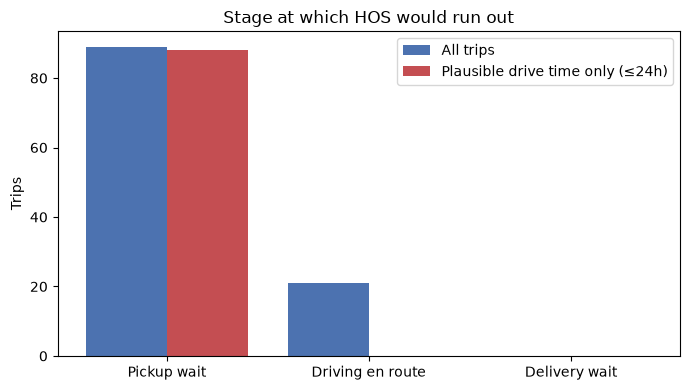

In [18]:
order = ['Ran out during pickup wait', 'Ran out while driving (en route)', 'Ran out during delivery wait']
raw = timeline['stage'].value_counts().reindex(order, fill_value=0)
plausible = timeline.loc[timeline['plausible_drive'], 'stage'].value_counts().reindex(order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(order))
ax.bar([i - 0.2 for i in x], raw.values, width=0.4, label='All trips', color='#4C72B0')
ax.bar([i + 0.2 for i in x], plausible.values, width=0.4, label='Plausible drive time only (≤24h)', color='#C44E52')
ax.set_xticks(list(x))
ax.set_xticklabels(['Pickup wait', 'Driving en route', 'Delivery wait'])
ax.set_ylabel('Trips')
ax.set_title('Stage at which HOS would run out')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
cols = ['NAME', 'TRIP_NUMBER', 'pickup_wait_h', 'drive_h', 'delivery_wait_h', 'REMAINING_HOURS', 'time_left_h']

print('Ran out during pickup wait (89 total, showing the 15 closest to zero):')
display(timeline.loc[timeline['stage'] == 'Ran out during pickup wait', cols]
        .sort_values('time_left_h', ascending=False).head(15))

Ran out during pickup wait (89 total, showing the 15 closest to zero):


,NAME,TRIP_NUMBER,pickup_wait_h,drive_h,delivery_wait_h,REMAINING_HOURS,time_left_h
39,Driver60,617100,0.000278,0.000278,0.000556,0.0,-0.001111
567,Driver60,618669,0.000278,0.000278,0.000833,0.0,-0.001389
266,Driver60,617815,0.000278,0.000278,0.000833,0.0,-0.001389
212,Driver60,617611,0.000278,0.000556,0.000833,0.0,-0.001667
1886,Driver56,622572,1.000000,1.000000,1.000278,0.0,-3.000278
1046,Driver56,620041,1.000000,1.000000,1.000278,0.0,-3.000278
949,Driver56,619747,1.000000,1.000000,1.000278,0.0,-3.000278
944,Driver13,619733,0.250000,2.250000,0.500278,0.0,-3.000278
912,Driver56,619655,1.000000,1.000000,1.000278,0.0,-3.000278
909,Driver13,619649,0.250000,2.250000,0.500278,0.0,-3.000278


In [20]:
print('Ran out while driving en route (all 21) — note every one has an implausible multi-day drive_h,')
print('a sign of a multi-stop join mismatch (see note above), not a genuine on-the-road HOS violation:')
display(timeline.loc[timeline['stage'] == 'Ran out while driving (en route)', cols]
        .sort_values('time_left_h').head(21))

Ran out while driving en route (all 21) — note every one has an implausible multi-day drive_h,
a sign of a multi-stop join mismatch (see note above), not a genuine on-the-road HOS violation:


,NAME,TRIP_NUMBER,pickup_wait_h,drive_h,delivery_wait_h,REMAINING_HOURS,time_left_h
635,Driver79,618851,6.889444,492.074167,0.752500,70.00,-429.716111
20,Driver31,616985,0.574444,402.338611,0.597500,20.97,-382.540556
30,Driver38,617039,0.548611,342.713611,0.825278,70.00,-274.087500
228,Driver55,617670,1.763056,254.444722,0.001667,65.19,-191.019444
224,Driver92,617652,2.122778,257.134444,0.001667,69.32,-189.938889
585,Driver101,618750,0.752222,232.531389,0.233611,70.00,-163.517222
1221,Driver25,620609,0.599444,183.104167,0.171944,35.17,-148.705556
1134,Driver51,620321,0.734444,176.068889,0.497222,62.85,-114.450556
606,Driver123,618795,3.766944,115.758333,0.940833,64.55,-55.916111
1430,Driver85,621234,3.500000,72.316667,0.283611,21.86,-54.240278


In [21]:
completed = timeline[(timeline['stage'] == 'Completed within available hours') & timeline['plausible_drive']]
print(f'Completed within available hours ({len(completed)} total, plausible-drive only, showing 15 with the least buffer left):')
display(completed[cols].sort_values('time_left_h').head(15))

Completed within available hours (866 total, plausible-drive only, showing 15 with the least buffer left):


,NAME,TRIP_NUMBER,pickup_wait_h,drive_h,delivery_wait_h,REMAINING_HOURS,time_left_h
1173,Driver31,620447,3.400000,2.446667,0.000833,20.97,15.122500
1747,Driver31,622191,3.391111,1.869722,0.251667,20.97,15.457500
1734,Driver85,622158,2.030556,2.066667,0.362222,21.86,17.400556
1026,Driver31,619959,0.551944,2.203056,0.702778,20.97,17.512222
1478,Driver31,621420,0.510556,2.471667,0.411111,20.97,17.576667
54,Driver31,617154,0.560278,2.465556,0.319167,20.97,17.625000
1220,Driver31,620603,0.583333,2.363333,0.288889,20.97,17.734444
1490,Driver31,621457,0.529444,2.066667,0.543056,20.97,17.830833
1735,Driver31,622159,0.571111,2.346667,0.215833,20.97,17.836389
1679,Driver31,621978,0.558611,2.176111,0.349444,20.97,17.885833


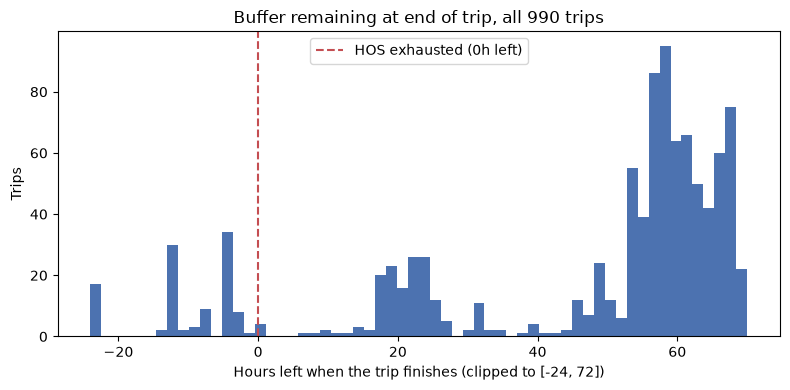

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(timeline['time_left_h'].clip(lower=-24, upper=72), bins=60, color='#4C72B0')
ax.axvline(0, color='#C44E52', linestyle='--', label='HOS exhausted (0h left)')
ax.set_xlabel('Hours left when the trip finishes (clipped to [-24, 72])')
ax.set_ylabel('Trips')
ax.set_title('Buffer remaining at end of trip, all 990 trips')
ax.legend()
plt.tight_layout()
plt.show()

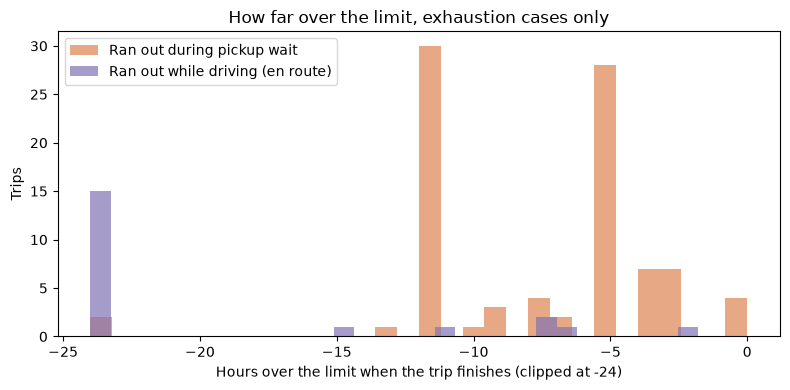

In [23]:
exhausted = timeline[timeline['stage'] != 'Completed within available hours']
fig, ax = plt.subplots(figsize=(8, 4))
for stage, color in [('Ran out during pickup wait', '#DD8452'), ('Ran out while driving (en route)', '#8172B2')]:
    ax.hist(exhausted.loc[exhausted['stage'] == stage, 'time_left_h'].clip(lower=-24),
            bins=30, alpha=0.7, label=stage, color=color)
ax.set_xlabel('Hours over the limit when the trip finishes (clipped at -24)')
ax.set_ylabel('Trips')
ax.set_title('How far over the limit, exhaustion cases only')
ax.legend()
plt.tight_layout()
plt.show()

**Correction to the earlier read:** all 21 "ran out while driving" trips turn out to have an implausible multi-day `drive_h` (66h to 492h) — a Southern Ontario regional haul doesn't take that long, so this is the multi-stop join mismatch flagged above, not real driving time. Once those are excluded, **zero trips show genuine HOS exhaustion from driving alone** in this dataset. What's left is **88 of 954 plausible-timeline trips (9%)** running out during the **pickup dock wait** — the same handful of drivers with a 0-hour live snapshot noted in section 1 account for most of them, and the histograms above show the rest sit only a few hours past zero. Delivery-wait exhaustion still doesn't happen on its own. Net: on the road, in this region, dock-side delay — not drive time — is the only signal in the data that actually holds up.

## 5. Yard shuttle / spotter moves

Sampling individual trips out of section 4 turned up a pattern: some legs have the *same* facility zone code on both ends and 0 miles, but still carry a real bill number, weight, and pallet count — a trailer being moved dock-to-dock or into a staging queue inside one facility, not driven over the road. That's a distinct operational role (yard jockey / spotter, common in automotive JIT sequencing), and it should be pulled out of the road-network analysis entirely: it will never register on a road-network geofence, and dispatch/ETA models built for line-haul don't apply to it.

The classifier only needs facts that exist on every leg, regardless of trip: same `LS_FROM_ZONE`/`LS_TO_ZONE`, `LS_LEG_DIST == 0`, and — for loaded legs — real freight attached, so it doesn't confuse this with the true zero-distance data stubs seen earlier (like trip 617100, a 3-second system record with no real dwell).

In [24]:
def classify_movement(legs):
    """Label each Dispatch leg as a real road move or an in-facility yard shuttle.

    A leg is a yard shuttle when its origin and destination are the *same*
    facility zone code, so LS_LEG_DIST is necessarily 0 -- the truck never
    left the property. Loaded shuttles are further required to carry real
    freight (weight/pallets/a bill number), which separates a genuine
    dock-to-dock or queue move from a bare administrative record.
    """
    same_facility = legs['LS_FROM_ZONE'].astype(str) == legs['LS_TO_ZONE'].astype(str)
    zero_dist = legs['LS_LEG_DIST'] == 0
    has_freight = (legs['WEIGHT_LBS'].fillna(0) > 0) | (legs['PALLETS'].fillna(0) > 0) | legs['LS_FREIGHT'].notna()

    movement_type = pd.Series('Line-haul / real road move', index=legs.index)
    movement_type[same_facility & zero_dist & (legs['LS_MT_LOADED'] == 'E')] = 'Yard shuttle (empty trailer)'
    movement_type[same_facility & zero_dist & (legs['LS_MT_LOADED'] == 'L') & has_freight] = 'Yard shuttle (loaded)'
    return movement_type


dispatch['movement_type'] = classify_movement(dispatch)
dispatch['movement_type'].value_counts()

movement_type
Line-haul / real road move      4939
Yard shuttle (loaded)            190
Yard shuttle (empty trailer)      63
Name: count, dtype: int64

In [25]:
yard_loaded = dispatch[dispatch['movement_type'] == 'Yard shuttle (loaded)'].copy()

print('Trips with at least one loaded yard-shuttle leg:', yard_loaded['TRIP_NUMBER'].nunique(), 'of', dispatch['TRIP_NUMBER'].nunique())
print('Drivers doing this work:', yard_loaded['NAME'].nunique())
print()
print('Top facilities (LS_FROM_ZONE):')
print(yard_loaded['LS_FROM_ZONE'].value_counts().head(6))
print()
print('Top drivers:')
print(yard_loaded['NAME'].value_counts().head(6))

Trips with at least one loaded yard-shuttle leg: 171 of 1326
Drivers doing this work: 18

Top facilities (LS_FROM_ZONE):
LS_FROM_ZONE
LEAWHI    104
RECOC      36
GMCAN      18
CPKGU       7
RECMI       6
RSTAR       5
Name: count, dtype: int64

Top drivers:
NAME
Driver13     40
Driver56     39
Driver40     36
Driver118    21
Driver97     15
Driver60      6
Name: count, dtype: int64


In [26]:
yard_loaded['arrive'] = pd.to_datetime(yard_loaded['LS_DET_PICK_ARRIVE'], errors='coerce')
yard_loaded['depart'] = pd.to_datetime(yard_loaded['LS_DET_DELV_ARRIVE'], errors='coerce')
yl = yard_loaded.dropna(subset=['arrive', 'depart']).copy()
yl['dur_h'] = (yl['depart'] - yl['arrive']).dt.total_seconds() / 3600
yl = yl[yl['dur_h'] >= 0]

bins = [-0.01, 0.1, 1, 4, 8, 24, 1e9]
labels = ['<6min (stub)', '6min-1h', '1-4h', '4-8h', '8-24h (full day)', '>24h (multi-day)']
yl['duration_bucket'] = pd.cut(yl['dur_h'], bins=bins, labels=labels)

print('Loaded yard-shuttle legs with a usable duration:', len(yl))
print(yl['duration_bucket'].value_counts().reindex(labels))
print()
print('Trips with a full-day-or-longer (>=8h) yard-shuttle leg:', yl.loc[yl['dur_h'] >= 8, 'TRIP_NUMBER'].nunique())

Loaded yard-shuttle legs with a usable duration: 147
duration_bucket
<6min (stub)         4
6min-1h              1
1-4h                53
4-8h                27
8-24h (full day)    55
>24h (multi-day)     7
Name: count, dtype: int64

Trips with a full-day-or-longer (>=8h) yard-shuttle leg: 57


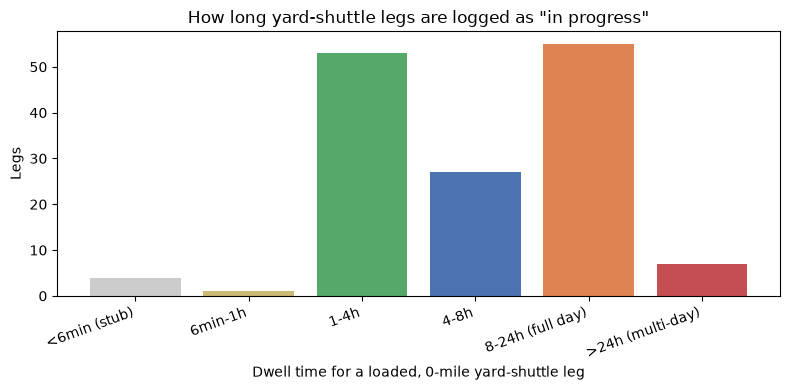

In [27]:
counts = yl['duration_bucket'].value_counts().reindex(labels)
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#CCCCCC', '#CCB974', '#55A868', '#4C72B0', '#DD8452', '#C44E52']
ax.bar(counts.index, counts.values, color=colors)
ax.set_xlabel('Dwell time for a loaded, 0-mile yard-shuttle leg')
ax.set_ylabel('Legs')
ax.set_title('How long yard-shuttle legs are logged as "in progress"')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

**190 loaded yard-shuttle legs across 171 ON-ON trips, done by 18 drivers** — every one carries real weight, pallets, and a bill number despite 0 road miles. One facility dominates: **Lear Whitby (`LEAWHI`) accounts for 104 of the 190**, consistent with automotive JIT sequencing (matches `RECOC`, `GMCAN`, `CPKGU` behind it — all OEM/tier-1 supplier codes). Of the 147 legs with a usable duration, **55 run 8-24h and 7 run over a full day** — 57 trips are logged as "in progress" for a full shift or more while never covering real distance. Only 4 are sub-6-minute administrative stubs like trip 617100 — genuine yard work, not paperwork noise, is the dominant pattern here.

**This is also the root cause of section 4's false "89 pickup-wait exhaustion" cases:** the same three drivers — `Driver13` (40 shuttle legs), `Driver56` (39), `Driver60` (6) — supply 88 of those 89. They aren't idling at a dock waiting for a load; they're the dedicated yard/local drivers doing exactly this work, on a live HOS snapshot that was never built to track it. Excluding `movement_type != 'Line-haul / real road move'` before any road-network HOS, detention-geofence, or dispatch-optimization model is the fix — these legs need their own operational model (a yard-management view), not the OTR one.

## 6. What kind of run is this? A full run-type taxonomy

Generalizing the yard-shuttle logic above into one classifier that sorts *every* ON-ON leg into one of six mutually exclusive run types:

- **Yard shuttle (loaded)** — same facility both ends, 0 miles, real freight (section 5)
- **Yard shuttle (empty trailer)** — same facility, 0 miles, no freight — a trailer swap/reposition inside the yard
- **Empty-pallet consolidation run** — `LOAD_DESCRIPTION == 'Empty pallets and palletized returns'`, a named business pattern (CPS Pallet Corp) that legitimately dwells for days while a full load builds
- **Empty repositioning / deadhead** — an `E` leg with real road miles between two different locations
- **Multi-stop consolidated freight (LTL)** — `LS_NUM_TOTAL > 1` or extra `LS_FREIGHT2/3/4` bill numbers on one leg: several orders combined onto one truck for efficiency
- **Point-to-point single load (FTL)** — everything left over: one pickup, one delivery, one bill, real miles — the plain vanilla case

Priority matters: a leg is only "yard shuttle" if it clears that bar first: a few pallet-consolidation and multi-stop legs also happen to land on 0 miles/same zone, so those checks run last and take precedence.

In [28]:
def classify_run_type(legs):
    """Sort every Dispatch leg into one of six mutually exclusive run types."""
    same_facility = legs['LS_FROM_ZONE'].astype(str) == legs['LS_TO_ZONE'].astype(str)
    zero_dist = legs['LS_LEG_DIST'] == 0
    has_freight = (legs['WEIGHT_LBS'].fillna(0) > 0) | (legs['PALLETS'].fillna(0) > 0) | legs['LS_FREIGHT'].notna()
    loaded, empty = legs['LS_MT_LOADED'] == 'L', legs['LS_MT_LOADED'] == 'E'
    pallet_run = legs['LOAD_DESCRIPTION'] == 'Empty pallets and palletized returns'
    multi_stop = (legs['LS_NUM_TOTAL'] > 1) | legs[['LS_FREIGHT2', 'LS_FREIGHT3', 'LS_FREIGHT4']].notna().any(axis=1)

    run_type = pd.Series('Point-to-point single load (FTL)', index=legs.index)
    run_type[empty] = 'Empty repositioning / deadhead'
    run_type[loaded & multi_stop] = 'Multi-stop consolidated freight (LTL)'
    run_type[loaded & pallet_run] = 'Empty-pallet consolidation run'
    run_type[same_facility & zero_dist & empty] = 'Yard shuttle (empty trailer)'
    run_type[same_facility & zero_dist & loaded & has_freight] = 'Yard shuttle (loaded)'
    return run_type


dispatch['run_type'] = classify_run_type(dispatch)
summary = dispatch['run_type'].value_counts().to_frame('legs')
summary['pct'] = (summary['legs'] / len(dispatch) * 100).round(1)
summary

,legs,pct
run_type,,
Point-to-point single load (FTL),2683,51.7
Empty repositioning / deadhead,1740,33.5
Multi-stop consolidated freight (LTL),342,6.6
Yard shuttle (loaded),190,3.7
Empty-pallet consolidation run,174,3.4
Yard shuttle (empty trailer),63,1.2


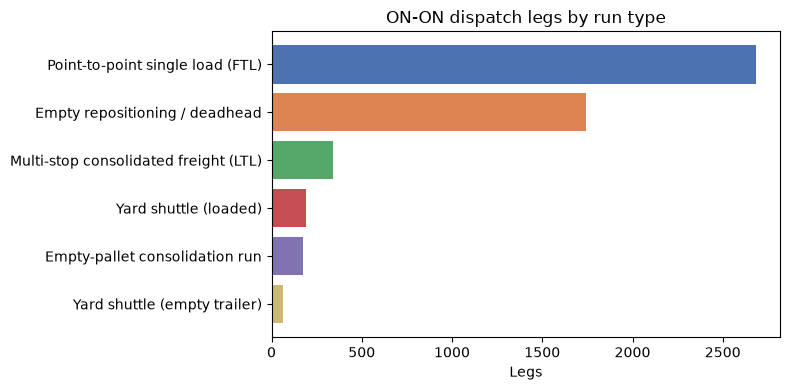

In [29]:
order = summary.index
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#CCB974']
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(order[::-1], summary['legs'][::-1], color=colors[::-1])
ax.set_xlabel('Legs')
ax.set_title('ON-ON dispatch legs by run type')
plt.tight_layout()
plt.show()

In [30]:
# LAST_FB_STATUS is a single last-known-status snapshot per leg, not a full event history --
# still useful as a cross-check: does each run type's last status make sense for what it claims to be?
pd.crosstab(dispatch['run_type'], dispatch['LAST_FB_STATUS'].fillna('(none)'))

LAST_FB_STATUS,(none),ARRCONS,ARRSHIP,ASSGN,AVAIL,COMPLETE,DEPSHIP,DISP,PICKD,SPTLD,STOPOFF
run_type,,,,,,,,,,,
Empty repositioning / deadhead,457,0,2,302,2,7,1,968,1,0,0
Empty-pallet consolidation run,1,0,0,0,0,147,1,0,0,25,0
Multi-stop consolidated freight (LTL),3,2,0,0,0,273,48,1,5,10,0
Point-to-point single load (FTL),28,3,0,0,0,1213,93,5,3,72,1266
Yard shuttle (empty trailer),40,0,3,4,1,0,0,14,0,0,1
Yard shuttle (loaded),0,1,0,0,0,148,0,0,0,7,34


Of 5,192 ON-ON legs: **52% are plain single-pickup-single-drop FTL hauls**, **33% are empty repositioning between real locations**, **7% are multi-stop LTL consolidation**, and the remaining **8% split across the three non-linehaul patterns** found by sampling — yard shuttles (loaded + empty, 4.9%) and empty-pallet consolidation runs (3.4%).

The status cross-tab is a sanity check, not a full audit trail (one status per leg, no history): yard-shuttle-loaded legs land overwhelmingly on `COMPLETE`/`STOPOFF`/`SPTLD` — a normal end-state for a finished internal move, no `DROMT` pileup or anomaly. Yard-shuttle-empty legs skew toward `(none)`/`DISP`/`ASSGN` — earlier-stage statuses, consistent with a trailer reposition that doesn't always get formally closed out the way a freight bill does. Nothing here reads as fabricated; it reads as two genuinely different business processes sharing one TMS.

`dispatch['run_type']` is now available for every downstream analysis — filter to `'Point-to-point single load (FTL)'` + `'Multi-stop consolidated freight (LTL)'` for anything meant to model real road-network behavior (HOS, detention-geofencing, dispatch/ETA optimization), and treat the other four as their own operational categories rather than noise to clean away.